<a href="https://colab.research.google.com/github/biplabp455/Skill-Morph-ML-Training/blob/main/Cancer_Detection_7th.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns


Now we will load the dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
print("Reading the real cancer dataset below....")
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('/content/drive/MyDrive/Dataset/Breast_Cancer_Wisconsin_Dataset.csv')
data.head()
data.info()



Reading the real cancer dataset below....
Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se  

In [ ]:
data.info()

NameError: name 'data' is not defined

Prepare Data

Reading the real cancer dataset below....
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X(measurements): (569, 5)
y(diagnosis): (569,)
Training: 455 patients (computer will learn from these)
analysis doctor training completed!
Now let's see how good our skill morph doctor is...

Analysis Doctor Accuracy: 0.904 (90.4%)
Good job! Our Analysis Doctor performs well

Confusion Matrix:
[[62  4]
 [ 7 41]]

Correct: 103

Incorrect: 11


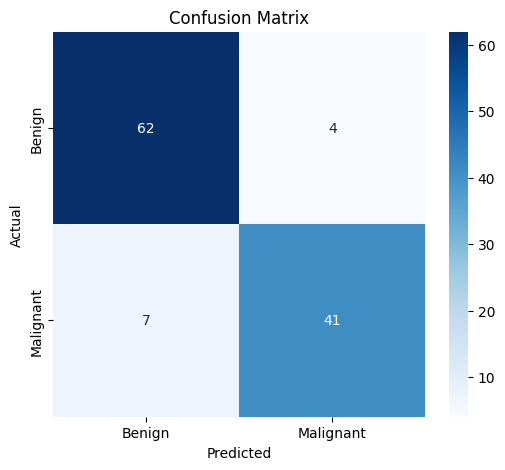


Accuracy : 0.90
precision: 0.91
recall: 0.85
f1: 0.88


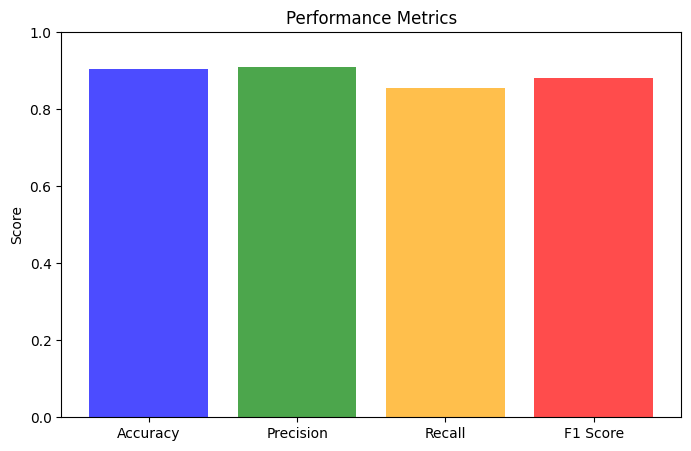

In [19]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
print("Reading the real cancer dataset below....")
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('/content/drive/MyDrive/Dataset/Breast_Cancer_Wisconsin_Dataset.csv')

# Convert Diagnosis from character data to Numeric data

data['diagnosis_numeric'] = data['diagnosis'].map({'M': 1, 'B': 0})

# We will select only important features

important_features = ['radius_mean',
                      'texture_mean',
                      'area_mean',
                      'smoothness_mean',
                      'compactness_mean'
]
# Now create simple dataset
X = data[important_features]
y = data['diagnosis_numeric']

print(f"X(measurements): {X.shape}")
print(f"y(diagnosis): {y.shape}")

# Train and Test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)
print(f"Training: {len(X_train)} patients (computer will learn from these)")
#print(f"Testing: {len(X_test)}patients (computer will be tested on these)")
#print(f"\training examples (computer learns from these):" )
#print(X_train.head())
#print(X_test.head())

# Now we will train the model with decision tree
#Creating model
analysis_doctor = DecisionTreeClassifier(
    max_depth = 4, #keep it simple
    random_state = 20
)
#print("Teaching analysis doctor with training data...")
#train the model
analysis_doctor.fit(X_train, y_train)
print("analysis doctor training completed!")
print("Now let's see how good our skill morph doctor is...")
#make prediction
predictions = analysis_doctor.predict(X_test)
#print("Skill Morph doctor made prediction for all test patients")
#Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\nAnalysis Doctor Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
if accuracy>0.95:
  print("Excellent! Our Analysis Doctor is very accurate")
elif accuracy>0.90:
  print("Good job! Our Analysis Doctor performs well")
elif accuracy>0.80:
  print("Ok! Our analysis doctor is decent")
else:
  print("Need to improve Analysis doctor")
# Now calculate the Confusion Matrix
cm = confusion_matrix(y_test, predictions)
print("\nConfusion Matrix:")
print(cm)
print(f"\nCorrect: {cm[0,0] + cm[1,1]}")
print(f"\nIncorrect: {cm[0,1] + cm[1,0]}")

#Now we will plot this

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels= ['Benign', 'Malignant'],
            yticklabels= ['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Matrix Calculation
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

# Now we will print them

print(f"\nAccuracy : {accuracy:.2f}")
print(f"precision: {precision:.2f}")
print(f"recall: {recall:.2f}")
print(f"f1: {f1:.2f}")

#Display it in simple bar chart

plt.figure(figsize=(8, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
plt.bar(metrics, values, color=['Blue', 'Green', 'Orange', 'Red'], alpha = 0.7)
plt.ylim(0, 1)
plt.title('Performance Metrics')
plt.ylabel('Score')
plt.show()




**Train & Test**